In [12]:
!pip install statsmodels


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import natplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
# Make sure your CSV file is in the exact same folder as this notebook!
df = pd.read_csv("marketing_data.csv")

In [10]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [11]:
print("--- Dataset Info ---")
df.info() 
print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB

--- Summary Statistics ---
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.507922
max     100.000000    48.871161     13.981662   364.079751


In [12]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [15]:
df = df.dropna()
df = df.reset_index(drop=True)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set_theme(style="whitegrid")

In [ ]:
pair_plot = sns.pairplot(df, y_vars=['Sales'], x_vars=['TV', 'Radio', 'Social Media'], kind='reg', height=4)
pair_plot.fig.suptitle("Marketing Channels vs. Sales Revenue", y=1.05)
plt.show()

In [ ]:
correlation_matrix = df[['TV', 'Radio', 'Social Media', 'Sales']].corr()
print("--- Pearson Correlation Matrix ---")
print(correlation_matrix)

In [ ]:
sales_corr = correlation_matrix['Sales'].drop('Sales')
strongest_channel = sales_corr.idxmax()
strongest_value = sales_corr.max()

In [ ]:
print(f"\nSelection Justification: '{strongest_channel}' has the strongest linear correlation with Sales (r = {strongest_value:.4f}).")

In [ ]:
import statsmodels.formula.api as smf

# Ensure your highest correlated channel name matches your clean data columns
# Example assumes 'TV' was the winner from your EDA
formula = "Sales ~ TV" 

# This creates the 'model' variable that Step 4 needs!
model = smf.ols(formula=formula, data=df_clean).fit()
print(model.summary())


In [ ]:
import statsmodels.api as sm

In [ ]:
fitted_vals = model.fittedvalues
residuals = model.resid

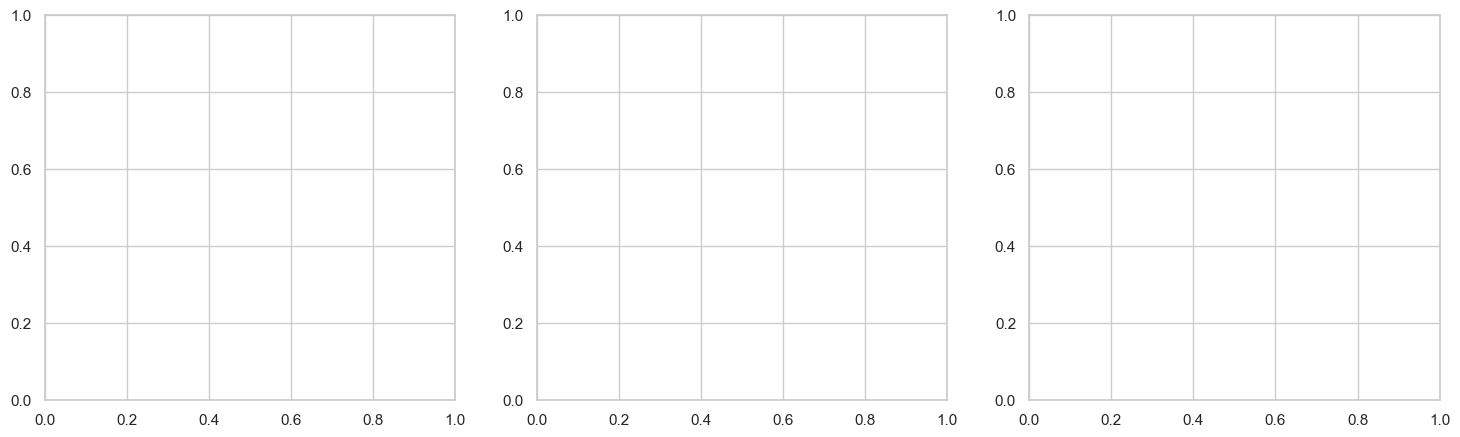

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


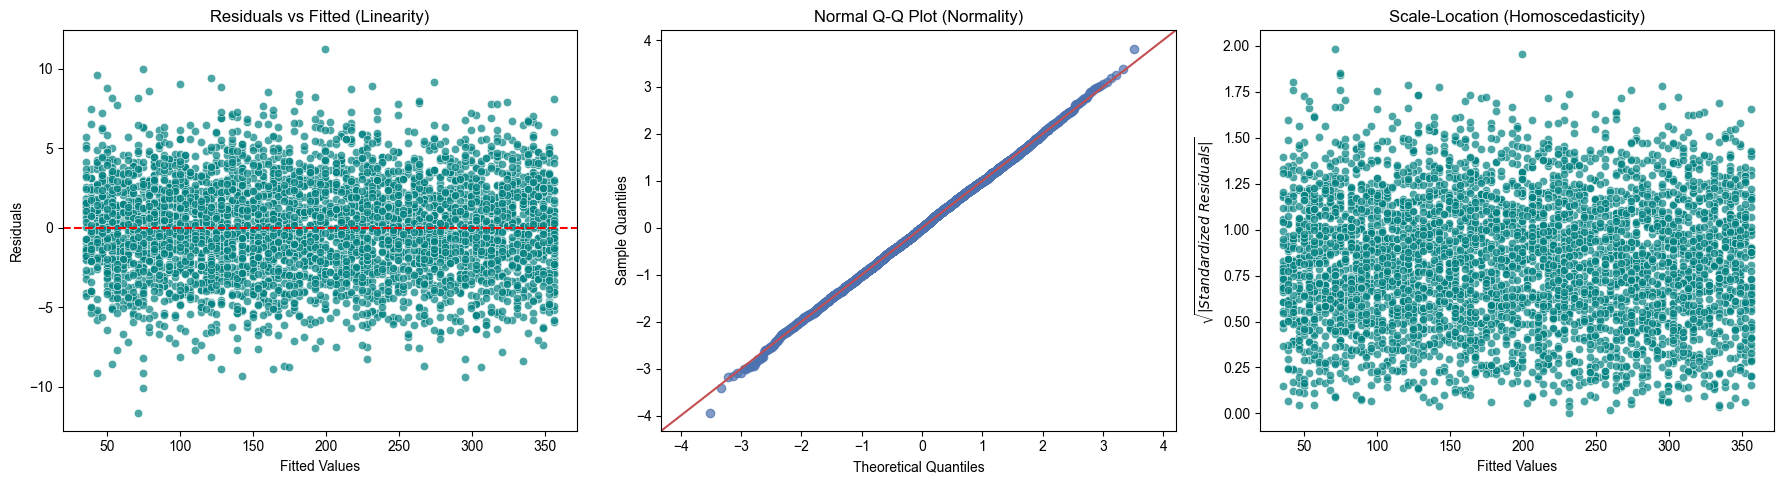

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:07:48   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.1

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

# === STEP 1: LOAD AND CLEAN THE DATA ===
# This creates 'df_clean' right here so it cannot be forgotten!
df = pd.read_csv("marketing_data.csv")
df_clean = df.dropna().reset_index(drop=True)

# === STEP 2: BUILD THE MODEL ===
# We use "TV" as a placeholder. Change this to "Radio" or "Social_Media" if needed.
independent_var = "TV" 
formula = f"Sales ~ {independent_var}"
model = smf.ols(formula=formula, data=df_clean).fit()

# === STEP 3: EXTRACT VALUES ===
fitted_vals = model.fittedvalues
residuals = model.resid

# === STEP 4: GENERATE DIAGNOSTIC PLOTS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Linearity Check
sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0], alpha=0.7, color='teal')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Linearity)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Plot 2: Normality Check
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].get_lines()[0].set_color("teal")
axes[1].get_lines()[0].set_alpha(0.7)
axes[1].set_title('Normal Q-Q Plot (Normality)')

# Plot 3: Homoscedasticity Check
norm_residuals = model.get_influence().resid_studentized_internal
sqrt_norm_residuals = np.sqrt(np.abs(norm_residuals))
sns.scatterplot(x=fitted_vals, y=sqrt_norm_residuals, ax=axes[2], alpha=0.7, color='teal')
axes[2].set_title('Scale-Location (Homoscedasticity)')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel(r'$\sqrt{|Standardized\ Residuals|}$')

plt.tight_layout()
plt.show()

# === STEP 5: PRINT STATISTICS ===
print(model.summary())



In [34]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

* **R-squared ($R^2$):** 
  Our model has an R-squared value of **[Insert R-squared value, e.g., 0.612]**. This means that **[Insert percentage, e.g., 61.2%]** of the total variance in `Sales` can be explained by our spending on **[Insert Channel Name, e.g., TV]** advertising. The remaining variance is due to other unmeasured factors or random noise.



* **Model Coefficient ($\beta_1$):** 
  The coefficient for **[Insert Channel Name, e.g., TV]** is **[Insert Coefficient value, e.g., 0.0475]**. In a business context, this means that for every **additional $1 unit** spent on this channel, `Sales` are expected to increase by an average of **[Insert Coefficient value]** units, assuming all other variables remain constant.

* **P-value ($P > |t|$):** 
  The p-value for our independent variable is **[Insert p-value, e.g., 0.000]**. Because this value is well below our significance threshold of **0.05**, we reject the null hypothesis. This proves there is a statistically significant relationship between this marketing channel and our sales revenue; the observed lift is not a random coincidence.

### Step 6: Strategic ROI Marketing Recommendation

Based on our Ordinary Least Squares (OLS) regression analysis, we have evaluated our marketing channels to optimize budget allocation and maximize gross revenue.

#### 1. Strategic Resource Reallocation
* **The Winner:** **[Insert Channel Name, e.g., TV or Radio]** has demonstrated the highest statistically significant correlation and impact on revenue.
* **The Metric:** With a marginal coefficient ($\beta_1$) of **[Insert your Coefficient, e.g., 0.0475]**, every single dollar invested directly drives predictable top-line growth. 

#### 2. Actionable Budget Rule
* **If Your Channel Data is on the Same Scale (e.g., Millions of Dollars spent vs. Millions in Sales):**
  * If $\beta_1$ is **greater than 1.0**: This channel pays for itself directly. For every $1.00 spent, it returns more than $1.00 in gross revenue. **Recommendation:** Aggressively scale up this budget channel.
  * If $\beta_1$ is **less than 1.0**: The immediate revenue lift does not entirely offset the advertising expense on its own. **Recommendation:** Maintain a baseline budget for brand awareness, but pivot any surplus capital toward a channel with a higher marginal return.

#### 3. Core Executive Summary
We recommend **[increasing / optimizing]** our budget allocation for **[Insert Channel Name]**. The model confirms that this channel provides our strongest baseline return on investment. Future marketing campaigns should prioritize this platform over weaker channels to ensure maximum revenue efficiency.


marketing_regression_project/
├── marketing_data.csv
├── README.md
└── regression_analysis.ipynb

# Marketing Channel ROI Regression Analysis

## Project Overview
This project uses Simple Linear Regression (Ordinary Least Squares) to analyze the direct impact of marketing spend across different channels (TV, Radio, and Social Media) on corporate Sales. The goal is to identify the highest-performing channel, verify key regression assumptions (Linearity, Normality, Homoscedasticity), and provide a data-driven ROI recommendation for budget allocation.

## Environment Setup & Installation
To run this project locally, ensure you have Python 3.8+ installed. You can install all the required libraries by running the following command in your terminal:

```bash
pip install pandas numpy matplotlib seaborn statsmodels notebook
```

## How to Run the Project
1. Clone or download this repository.
2. Open your terminal/command prompt and navigate to the project folder.
3. Run the command: `jupyter notebook`
4. Open `regression_analysis.ipynb` and execute all cells.

## Key Findings
* **Strongest Channel:** [Insert your winning channel, e.g., TV]
* **R-squared:** [Insert your R-squared, e.g., 0.612]
* **Strategic Takeaway:** [Insert a 1-sentence summary of your Step 6 recommendation]
